# Pràctica 4 — Similitud Lèxica i Semàntica

Entrenament i avaluació de models d'embeddings distribucionals i contextuals per a tasques de similitud en espanyol.

**Datasets**
- **Multi-SimLex (Spanish)** — parells de paraules → avaluació *intrínseca* (Spearman)
- **Spanish STS (PlanTL-GOB-ES)** — parells de frases → avaluació *extrínseca* (Pearson)
- **Wikicorpus** en espanyol per entrenar embeddings

## 0. Setup

Instal·lacions, imports i configuració global.

In [1]:
# Instal·la dependències
# !pip install -q gensim==4.3.* transformers datasets torch scikit-learn pandas tqdm huggingface_hub

In [1]:
import os
import re
import gzip
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr, spearmanr

# Reproductibilitat
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositiu: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositiu: cpu
PyTorch: 2.11.0+cpu


In [53]:
# Constants i directoris

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Hiperparàmetres globals per a models Word2Vec i fastText (Tasques 1 i 2)
W2V_DIMS = [50, 100, 200, 300, 400]   
FT_DIMS = [50, 100, 200, 300]                  
W2V_EPOCHS = 10
W2V_WINDOW = 5
W2V_MIN_COUNT = 5

# Hiperparàmetres dels models neurals (Tasques 3+)
MAX_LEN_SEQ = 64
BATCH_SIZE = 32
SIAMESE_EPOCHS = 10
SIAMESE_LR = 1e-3
BERT_EPOCHS = 4
BERT_LR = 2e-5
BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO


## 1. Descàrrega, càrrega i inspecció de dades

Tres fonts: el Wikicorpus per entrenar embeddings, Spanish STS per a l'avaluació extrínseca, i Multi-SimLex per a l'avaluació intrínseca.

### 1.1 Wikicorpus

In [4]:
import urllib.request
import tarfile

WIKI_URL = "https://www.cs.upc.edu/~nlp/wikicorpus/raw.es.tgz"
WIKI_TGZ = DATA_DIR / "raw.es.tgz"
WIKI_DIR = DATA_DIR / "raw.es"

if not WIKI_TGZ.exists() or WIKI_TGZ.stat().st_size < 100_000_000:
    print("Descarregant Wikicorpus...")
    urllib.request.urlretrieve(WIKI_URL, WIKI_TGZ)
print(f"Carregat: {WIKI_TGZ}  ({WIKI_TGZ.stat().st_size:,} bytes)")

WIKI_DIR.mkdir(exist_ok=True)
if not any(p.is_file() for p in WIKI_DIR.rglob("*")):
    print("Descomprimint...")
    with tarfile.open(WIKI_TGZ, "r:gz") as tar:
        tar.extractall(WIKI_DIR, filter="data")
    print("Extracció completa")

files = [p for p in WIKI_DIR.rglob("*") if p.is_file()]
print(f"Total fitxers extrets: {len(files)}")

Carregat: data\raw.es.tgz  (252,926,918 bytes)
Total fitxers extrets: 57


#### Tokenitzador i càrrega de frases

In [5]:
# Tokenitzador
# Preprocess: minúscules, extracció de tokens alfanumèrics, filtre de frases curtes (min_tokens=3) i min_count=5

WORD_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def tokenize(text):
    return WORD_RE.findall(text.lower())

def iter_wikicorpus_sentences(wiki_dir, max_sentences=None, min_tokens=3):
    """Itera sobre frases tokenitzades del Wikicorpus en streaming."""
    sent_split = re.compile(r"[.!?¡¿]+")
    n = 0
    files = sorted(p for p in Path(wiki_dir).rglob("*") if p.is_file())
    for fp in files:
        try:
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("<doc") \
                       or line.startswith("</doc") \
                       or line.startswith("ENDOFARTICLE"):
                        continue
                    for sent in sent_split.split(line):
                        toks = tokenize(sent)
                        if len(toks) >= min_tokens:
                            yield toks
                            n += 1
                            if max_sentences is not None and n >= max_sentences:
                                return
        except Exception:
            continue

In [7]:
# Càrrega de sentences (corpus complet)
from collections import Counter

sentences = list(iter_wikicorpus_sentences(WIKI_DIR, max_sentences=None))

all_tokens   = [tok for sent in sentences for tok in sent]
vocab_counter = Counter(all_tokens)
vocab_above  = sum(1 for f in vocab_counter.values() if f >= W2V_MIN_COUNT)

print(f"Frases           : {len(sentences):,}")
print(f"Tokens totals    : {len(all_tokens):,}")
print(f"Vocabulari únic  : {len(vocab_counter):,}")
print(f"Longitud mitjana : {len(all_tokens)/len(sentences):.1f} toks/frase")
print(f"Paraules >= min_count={W2V_MIN_COUNT}: {vocab_above:,} ({vocab_above/len(vocab_counter)*100:.1f}%)")
print(f"Top-10 paraules  : {vocab_counter.most_common(10)}")

Frases           : 5,847,015
Tokens totals    : 101,786,019
Vocabulari únic  : 1,122,904
Longitud mitjana : 17.4 toks/frase
Paraules >= min_count=5: 296,763 (26.4%)
Top-10 paraules  : [('de', 7764258), ('la', 4051799), ('en', 3384154), ('el', 3058034), ('y', 2645922), ('a', 1792421), ('que', 1682921), ('los', 1451190), ('del', 1390945), ('se', 1163272)]


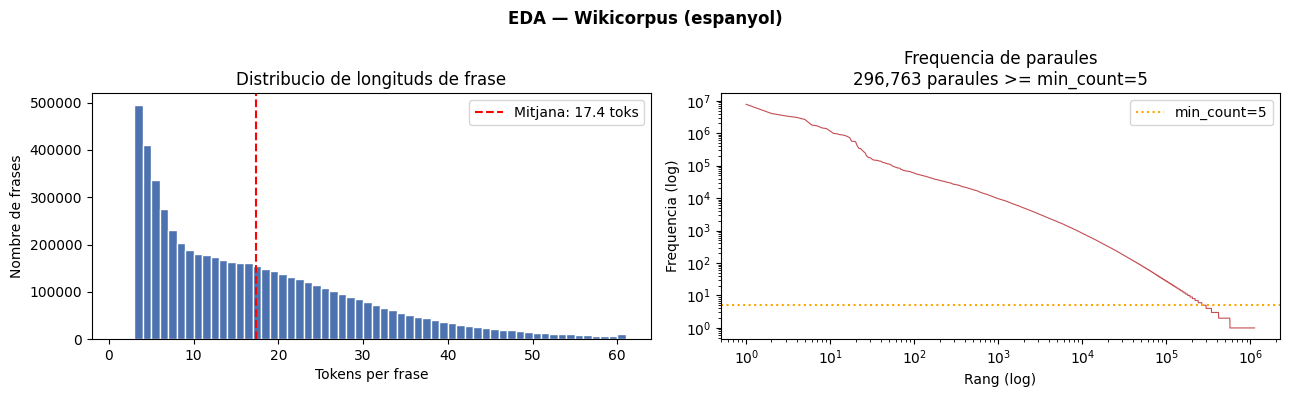

Frases amb >60 tokens (no mostrades al histograma): 1.3%


In [8]:
import matplotlib.pyplot as plt

sent_lengths = [len(s) for s in sentences]
mean_len = sum(sent_lengths) / len(sent_lengths)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("EDA — Wikicorpus (espanyol)", fontweight="bold")

# Esquerra: histograma de longituds de frase
# bins=range(1,62) => un bin per token; frases >60 toks s'ometen del grafic
axes[0].hist(sent_lengths, bins=range(1, 62), color="#4C72B0", edgecolor="white")
axes[0].axvline(mean_len, color="red", linestyle="--",
                label=f"Mitjana: {mean_len:.1f} toks")
axes[0].set_title("Distribucio de longituds de frase")
axes[0].set_xlabel("Tokens per frase")
axes[0].set_ylabel("Nombre de frases")
axes[0].legend()

# Dreta: Rang vs frequencia, escala log-log
freqs = sorted(vocab_counter.values(), reverse=True)
axes[1].loglog(range(1, len(freqs)+1), freqs, color="#C44E52", linewidth=0.8)
axes[1].axhline(W2V_MIN_COUNT, color="orange", linestyle=":",
                linewidth=1.5, label=f"min_count={W2V_MIN_COUNT}")
axes[1].set_title(f"Frequencia de paraules\n"
                  f"{vocab_above:,} paraules >= min_count={W2V_MIN_COUNT}")
axes[1].set_xlabel("Rang (log)")
axes[1].set_ylabel("Frequencia (log)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_wikicorpus.png", dpi=150, bbox_inches="tight")
plt.show()

pct_over60 = sum(1 for l in sent_lengths if l > 60) / len(sent_lengths) * 100
print(f"Frases amb >60 tokens (no mostrades al histograma): {pct_over60:.1f}%")

### 1.2 Spanish STS

In [ ]:
from datasets import load_dataset

sts = load_dataset("PlanTL-GOB-ES/sts-es")
print(sts)

train_df = sts["train"].to_pandas()
dev_df   = sts["validation"].to_pandas()
test_df  = sts["test"].to_pandas()

for df in [train_df, dev_df, test_df]:
    if "label" in df.columns and "score" not in df.columns:
        df.rename(columns={"label": "score"}, inplace=True)

print(f"\nTrain: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
print(train_df.head(3))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Spanish STS", fontweight="bold")

colors = {"Train": "#4C72B0", "Dev": "#55A868", "Test": "#C44E52"}
splits = {"Train": train_df,   "Dev": dev_df,    "Test": test_df}

for name, df_s in splits.items():
    axes[0].hist(df_s["score"], bins=15, alpha=0.6,
                 label=f"{name} (n={len(df_s)})", color=colors[name], edgecolor="white")
axes[0].set_title("Distribució de scores per split")
axes[0].set_xlabel("Score (0–5)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

bp = axes[1].boxplot([df_s["score"].values for df_s in splits.values()],
                     labels=splits.keys(), patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Scores per split (boxplot)")
axes[1].set_ylabel("Score (0–5)")

all_sents = pd.concat([df_s[col] for df_s in splits.values()
                        for col in ["sentence1", "sentence2"]])
lengths = all_sents.str.split().apply(len)
axes[2].hist(lengths, bins=30, color="#8172B2", edgecolor="white")
axes[2].axvline(lengths.mean(), color="red", linestyle="--",
                label=f"Mitjana: {lengths.mean():.1f} toks")
axes[2].axvline(MAX_LEN_SEQ, color="orange", linestyle=":",
                linewidth=2, label=f"MAX_LEN_SEQ={MAX_LEN_SEQ}")
axes[2].set_title("Longitud de frases (tokens)")
axes[2].set_xlabel("Nombre de tokens")
axes[2].set_ylabel("Freqüència")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_sts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Split':<8} {'N':>5}  {'min':>5} {'max':>5} {'mitjà':>7}  {'long. frase mitjana':>20}")
print("-" * 58)
for name, df_s in splits.items():
    lens = pd.concat([df_s["sentence1"], df_s["sentence2"]]).str.split().apply(len)
    print(f"{name:<8} {len(df_s):>5}  {df_s['score'].min():>5.1f} "
          f"{df_s['score'].max():>5.1f} {df_s['score'].mean():>7.3f}  "
          f"{lens.mean():>20.1f}")
pct = (lengths > MAX_LEN_SEQ).mean() * 100
print(f"\nFrases > MAX_LEN_SEQ ({MAX_LEN_SEQ}): "
      f"{(lengths > MAX_LEN_SEQ).sum()} ({pct:.1f}%) → seran truncades")

In [ ]:
# Vocabulari únic del corpus STS 
# Per estimar la cobertura dels embeddings sobre el conjunt d'avaluació
all_words_sts = set()
word_freq_sts  = Counter()
for df_s in [train_df, dev_df, test_df]:
    for col in ["sentence1", "sentence2"]:
        for sent in df_s[col]:
            toks = tokenize(sent)
            all_words_sts.update(toks)
            word_freq_sts.update(toks)

n_frases = sum(len(df_s) * 2 for df_s in [train_df, dev_df, test_df])
print(f"Frases totals (tots els splits) : {n_frases:,}")
print(f"Vocabulari únic al corpus STS   : {len(all_words_sts):,} paraules")
print(f"Top-10 paraules més freqüents   : {word_freq_sts.most_common(10)}")

### 1.3 Multi-SimLex (Spanish)

In [9]:
import urllib.request

MULTISIMLEX_PATH = DATA_DIR / "multisimlex_spa.csv"
MULTISIMLEX_URL  = "https://web.archive.org/web/20231020014354id_/https://multisimlex.com/data/SPA.csv"

if not MULTISIMLEX_PATH.exists():
    urllib.request.urlretrieve(MULTISIMLEX_URL, MULTISIMLEX_PATH)

# Inspecció format: "ID, Word_1, Word_2..."
print(MULTISIMLEX_PATH.read_text(encoding="utf-8")[:500])

ID,Word 1,Word 2,PoS,Annotator 1,Annotator 2,Annotator 3,Annotator 4,Annotator 5,Annotator 6,Annotator 7,Annotator 8,Annotator 9,Annotator 10
1,brazo,músculo,nouns,1,1,5,0,0,0,2,1,2,2
2,democracia,monarquía,nouns,0,0,3,0,0,0,2,1,3,4
3,tejado,techo,nouns,5,5,6,4,5,3,4,4,6,6
4,amigo,profesor,nouns,0,0,1,0,0,0,2,0,1,0
5,mano,pie,nouns,1,0,3,0,0,0,2,1,3,1
6,biografía,ficción,nouns,1,1,2,0,0,0,0,0,2,1
7,disco,ordenador,nouns,0,1,4,0,0,0,2,2,1,3
8,Esgrima,gimnasia,nouns,1,2,6,2,3,0,3,1,4,4
9,banco,asi


In [10]:
multisimlex_df = pd.read_csv(MULTISIMLEX_PATH, sep=",")

cols_lower = {c.lower(): c for c in multisimlex_df.columns}

def find_col(candidates):
    for n in candidates:
        if n.lower() in cols_lower:
            return cols_lower[n.lower()]
    return None

W1_COL    = find_col(["word1", "word 1", "word_1", "w1"])
W2_COL    = find_col(["word2", "word 2", "word_2", "w2"])
SCORE_COL = find_col(["score", "mean", "similarity", "rating"])

# Multi-SimLex (Spanish) no té score precalculat:
# calculem la mitjana dels 10 anotadors
if SCORE_COL is None:
    annotator_cols = [c for c in multisimlex_df.columns if c.lower().startswith("annotator")]
    multisimlex_df["score"] = multisimlex_df[annotator_cols].mean(axis=1)
    SCORE_COL = "score"

multisimlex_pairs = list(zip(
    multisimlex_df[W1_COL].astype(str).str.lower(),
    multisimlex_df[W2_COL].astype(str).str.lower(),
    multisimlex_df[SCORE_COL].astype(float),
))

print(f"Total parells Multi-SimLex: {len(multisimlex_pairs)}")
print("Exemples:", multisimlex_pairs[:3])

Total parells Multi-SimLex: 1888
Exemples: [('brazo', 'músculo', 1.4), ('democracia', 'monarquía', 1.3), ('tejado', 'techo', 4.8)]


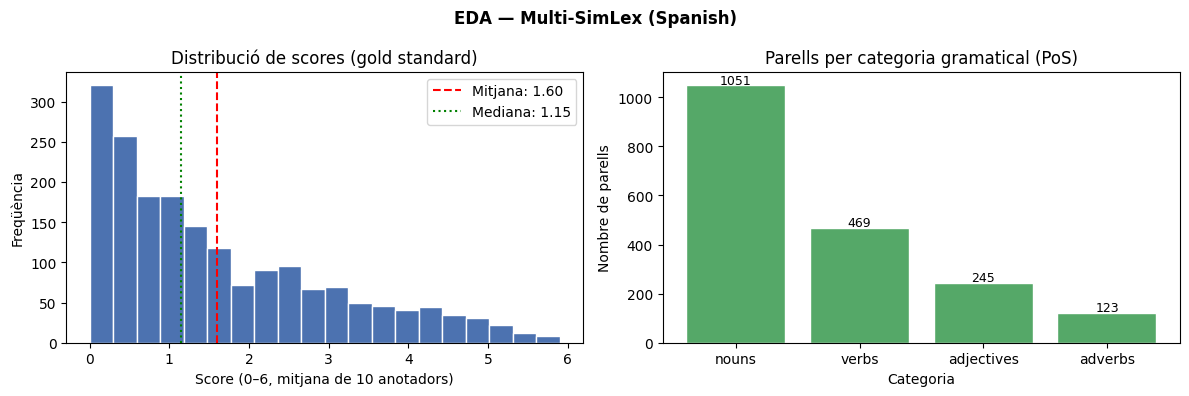

Parells totals     : 1,888
Score — mínim: 0.00 | màxim: 5.90 | mitjà: 1.60 | mediana: 1.15 | std: 1.43
Parells score = 0  (no similars) : 98
Parells score ≥ 5  (molt similars): 51


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("EDA — Multi-SimLex (Spanish)", fontweight="bold")

axes[0].hist(multisimlex_df["score"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(multisimlex_df["score"].mean(), color="red", linestyle="--",
                label=f"Mitjana: {multisimlex_df['score'].mean():.2f}")
axes[0].axvline(multisimlex_df["score"].median(), color="green", linestyle=":",
                label=f"Mediana: {multisimlex_df['score'].median():.2f}")
axes[0].set_title("Distribució de scores (gold standard)")
axes[0].set_xlabel("Score (0–6, mitjana de 10 anotadors)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

pos_counts = multisimlex_df["PoS"].value_counts()
bars = axes[1].bar(pos_counts.index, pos_counts.values, color="#55A868", edgecolor="white")
for bar, v in zip(bars, pos_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha="center", fontsize=9)
axes[1].set_title("Parells per categoria gramatical (PoS)")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Nombre de parells")

plt.tight_layout()
plt.savefig("eda_multisimlex.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Parells totals     : {len(multisimlex_pairs):,}")
print(f"Score — mínim: {multisimlex_df['score'].min():.2f} | "
      f"màxim: {multisimlex_df['score'].max():.2f} | "
      f"mitjà: {multisimlex_df['score'].mean():.2f} | "
      f"mediana: {multisimlex_df['score'].median():.2f} | "
      f"std: {multisimlex_df['score'].std():.2f}")
print(f"Parells score = 0  (no similars) : {(multisimlex_df['score'] == 0).sum()}")
print(f"Parells score ≥ 5  (molt similars): {(multisimlex_df['score'] >= 5).sum()}")

## 2. Tasca 1 — Entrenament d'embeddings estatics

Entrenem embeddings distribucionals sobre el Wikicorpus en espanyol.

**Models entrenats:**
- §2.1 Word2Vec **CBOW** — ablacio de dimensionalitat {50, 100, 200, 300, 400} sobre ~50M tokens
- §2.2 Word2Vec **CBOW** — ablacio de mida del corpus {~10M, ~25M, ~50M, tot} amb dim=300
- §2.3 fastText **CBOW** — ablacio de dimensionalitat {50, 100, 200, 300} sobre ~50M tokens
- §2.4 fastText **CBOW** — ablacio de mida del corpus {~10M, ~25M, ~50M, tot} amb dim=300
- §2.5 Wrappers FastText per a l'avaluacio OOV

**Hiperparametres compartits** (Word2Vec i fastText propi):

| Parametre     | Valor              | Descripcio                          |
|---------------|--------------------|-------------------------------------|
| `sg`          | 0                  | CBOW (prediu paraula central)       |
| `window`      | `W2V_WINDOW` = 5   | Finestra de context (+/-5 paraules) |
| `min_count`   | `W2V_MIN_COUNT` = 5| Descarta paraules amb freq < 5      |
| `epochs`      | `W2V_EPOCHS` = 10  | Passades sobre el corpus            |
| `seed`        | `SEED` = 42        | Reproduibilitat                     |

### 2.1 Word2Vec CBOW — ablacio de dimensionalitat

CBOW prediu la paraula central a partir de les paraules de context.
Comparem quatre dimensions sobre un corpus de referencia de ~50M tokens per aïllar
l'efecte de la dimensionalitat del de la mida del corpus.

| Parametre       | Valor                |
|-----------------|----------------------|
| `vector_size`   | {50, 100, 200, 300, 400}   |
| `window`        | `W2V_WINDOW` = 5     |
| `min_count`     | `W2V_MIN_COUNT` = 5  |
| `epochs`        | `W2V_EPOCHS` = 10    |
| `sg`            | 0 (CBOW)             |
| Corpus          | ~50M tokens          |

In [12]:
from gensim.models import Word2Vec

def sentences_up_to_tokens(sents, target_tokens):
    """Retorna les primeres frases fins acumular ~target_tokens tokens."""
    acc, subset = 0, []
    for s in sents:
        subset.append(s)
        acc += len(s)
        if acc >= target_tokens:
            break
    return subset

REF_TOKENS    = 50_000_000
sentences_50M = sentences_up_to_tokens(sentences, REF_TOKENS)
real_tok_50M  = sum(len(s) for s in sentences_50M)
print(f"Subconjunt de referencia: {len(sentences_50M):,} frases, {real_tok_50M/1e6:.1f}M tokens")

W2V_DIMS = [50, 100, 200, 300, 400]

w2v_models = {}
for dim in W2V_DIMS:
    out_path = MODELS_DIR / f"w2v_cbow_{dim}d.model"
    if out_path.exists():
        m = Word2Vec.load(str(out_path))
        estat = "carregat"
    else:
        m = Word2Vec(
            sentences=sentences_50M,
            vector_size=dim,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
        )
        m.save(str(out_path))
        estat = "entrenat"
    w2v_models[dim] = m
    print(f"  w2v-cbow-{dim:3d}d | {estat:8s} | vocab: {len(m.wv):>6,} | {out_path.name}")

Subconjunt de referencia: 2,822,112 frases, 50.0M tokens
  w2v-cbow- 50d | carregat | vocab: 192,857 | w2v_cbow_50d.model
  w2v-cbow-100d | carregat | vocab: 192,857 | w2v_cbow_100d.model
  w2v-cbow-200d | carregat | vocab: 192,857 | w2v_cbow_200d.model
  w2v-cbow-300d | carregat | vocab: 192,857 | w2v_cbow_300d.model
  w2v-cbow-400d | carregat | vocab: 192,857 | w2v_cbow_400d.model


### 2.2 Word2Vec CBOW — ablacio de mida del corpus

Fixem dim=300 i CBOW, i variem la mida del corpus expressada en tokens acumulats.

El cas `50M` reutilitza el model entrenat a §2.1 (mateixa dimensio i corpus). El cas `all` usa el corpus complet.

| Parametre      | Valor                              |
|----------------|------------------------------------|
| `vector_size`  | `ABLATION_DIM` = 300               |
| `window`       | `W2V_WINDOW` = 5                   |
| `min_count`    | `W2V_MIN_COUNT` = 5                |
| `epochs`       | `W2V_EPOCHS` = 10                  |
| `sg`           | 0 (CBOW)                           |
| Corpus         | {~10M, ~25M, ~50M*, tot} tokens    |

In [13]:
ABLATION_DIM = 300

# sentences_up_to_tokens ja definida a §2.1
CORPUS_SIZES = {
    "10M": 10_000_000,
    "25M": 25_000_000,
}

w2v_ablation = {}

# Subsets 10M i 25M: entrenament propi
for label, target_tok in CORPUS_SIZES.items():
    out_path = MODELS_DIR / f"w2v_cbow_{ABLATION_DIM}d_{label}.model"
    if out_path.exists():
        m = Word2Vec.load(str(out_path))
        estat = "carregat"
    else:
        subset   = sentences_up_to_tokens(sentences, target_tok)
        real_tok = sum(len(s) for s in subset)
        m = Word2Vec(
            sentences=subset,
            vector_size=ABLATION_DIM,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
        )
        m.save(str(out_path))
        estat = f"entrenat({real_tok/1e6:.1f}M tok)"
    w2v_ablation[label] = m
    print(f"  w2v-cbow-{ABLATION_DIM}d-{label:3s} | {estat:25s} | "
          f"vocab: {len(m.wv):>6,} | {out_path.name}")

# Cas '50M': reutilitza el model de §2.1 (mateixa dim i corpus)
m50 = w2v_models[ABLATION_DIM]
w2v_ablation["50M"] = m50
print(f"  w2v-cbow-{ABLATION_DIM}d-50M | {'reutilitzat (§2.1)':25s} | "
      f"vocab: {len(m50.wv):>6,} | w2v_cbow_{ABLATION_DIM}d.model")

# Cas 'all': corpus complet
all_path = MODELS_DIR / f"w2v_cbow_{ABLATION_DIM}d_all.model"
if all_path.exists():
    m_all = Word2Vec.load(str(all_path))
    estat  = "carregat"
else:
    m_all = Word2Vec(
        sentences=sentences,
        vector_size=ABLATION_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=4,
        sg=0,
        epochs=W2V_EPOCHS,
        seed=SEED,
    )
    m_all.save(str(all_path))
    estat = "entrenat(corpus complet)"
w2v_ablation["all"] = m_all
print(f"  w2v-cbow-{ABLATION_DIM}d-all | {estat:25s} | "
      f"vocab: {len(m_all.wv):>6,} | {all_path.name}")

  w2v-cbow-300d-10M | carregat                  | vocab: 73,621 | w2v_cbow_300d_10M.model
  w2v-cbow-300d-25M | carregat                  | vocab: 126,191 | w2v_cbow_300d_25M.model
  w2v-cbow-300d-50M | reutilitzat (§2.1)        | vocab: 192,857 | w2v_cbow_300d.model
  w2v-cbow-300d-all | carregat                  | vocab: 296,763 | w2v_cbow_300d_all.model


### 2.3 fastText CBOW — ablacio de dimensionalitat

Reproduim l'experiment de §2.1 amb fastText CBOW: comparem tres dimensions sobre el subconjunt de referencia de ~50M tokens.
fastText afegeix n-grams de caracters (min_n=3, max_n=6) que permeten
representar paraules OOV.

| Parametre       | Valor                |
|-----------------|----------------------|
| `vector_size`   | {50, 100, 200, 300}  |
| `window`        | `W2V_WINDOW` = 5     |
| `min_count`     | `W2V_MIN_COUNT` = 5  |
| `epochs`        | `W2V_EPOCHS` = 10    |
| `sg`            | 0 (CBOW)             |
| `min_n / max_n` | 3 / 6                |
| Corpus          | ~50M tokens          |

In [14]:
from gensim.models import FastText


# sentences_50M i sentences_up_to_tokens ja definits a §2.1
ft_models = {}
for dim in FT_DIMS:  # [50, 100, 200, 300]
    out_path = MODELS_DIR / f"fasttext_cbow_{dim}d.model"
    if out_path.exists():
        m = FastText.load(str(out_path))
        estat = "carregat"
    else:
        m = FastText(
            sentences=sentences_50M,
            vector_size=dim,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
            min_n=3,
            max_n=6,
        )
        m.save(str(out_path))
        estat = "entrenat"
    ft_models[dim] = m
    print(f"  ft-cbow-{dim:3d}d | {estat:8s} | vocab: {len(m.wv):>6,} | {out_path.name}")

  ft-cbow- 50d | carregat | vocab: 192,857 | fasttext_cbow_50d.model
  ft-cbow-100d | carregat | vocab: 192,857 | fasttext_cbow_100d.model
  ft-cbow-200d | carregat | vocab: 192,857 | fasttext_cbow_200d.model
  ft-cbow-300d | carregat | vocab: 192,857 | fasttext_cbow_300d.model


### 2.4 fastText CBOW — ablacio de mida del corpus

Reproduim l'experiment de §2.2 amb fastText CBOW: fixem dim=300 i
variem la mida del corpus expressada en recompte de tokens.
El cas `50M` reutilitza el model entrenat a §2.3 (mateixa dimensio i corpus).
El cas `all` usa el corpus complet.

| Parametre       | Valor                              |
|-----------------|------------------------------------|
| `vector_size`   | 300                                |
| `window`        | `W2V_WINDOW` = 5                   |
| `min_count`     | `W2V_MIN_COUNT` = 5                |
| `epochs`        | `W2V_EPOCHS` = 10                  |
| `sg`            | 0 (CBOW)                           |
| `min_n / max_n` | 3 / 6                              |
| Corpus          | {~10M, ~25M, ~50M*, tot} tokens    |

In [16]:
from gensim.models import Word2Vec
from gensim.models import FastText

FT_ABLATION_DIM = 300

# sentences_up_to_tokens ja definida a §2.1
FT_CORPUS_SIZES = {
    "10M": 10_000_000,
    "25M": 25_000_000,
}

ft_ablation = {}

# Subsets 10M i 25M: entrenament propi
for label, target_tok in FT_CORPUS_SIZES.items():
    out_path = MODELS_DIR / f"fasttext_cbow_{FT_ABLATION_DIM}d_{label}.model"
    if out_path.exists():
        m = FastText.load(str(out_path))
        estat = "carregat"
    else:
        subset   = sentences_up_to_tokens(sentences, target_tok)
        real_tok = sum(len(s) for s in subset)
        m = FastText(
            sentences=subset,
            vector_size=FT_ABLATION_DIM,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
            min_n=3,
            max_n=6,
        )
        m.save(str(out_path))
        estat = f"entrenat({real_tok/1e6:.1f}M tok)"
    ft_ablation[label] = m
    print(f"  ft-cbow-{FT_ABLATION_DIM}d-{label:3s} | {estat:25s} | "
          f"vocab: {len(m.wv):>6,} | {out_path.name}")

# Cas '50M': reutilitza el model de §2.3 (mateixa dim i corpus)
m50 = ft_models[FT_ABLATION_DIM]
ft_ablation["50M"] = m50
print(f"  ft-cbow-{FT_ABLATION_DIM}d-50M | {'reutilitzat (§2.3)':25s} | "
      f"vocab: {len(m50.wv):>6,} | fasttext_cbow_{FT_ABLATION_DIM}d.model")

# Cas 'all': corpus complet
all_path = MODELS_DIR / f"fasttext_cbow_{FT_ABLATION_DIM}d_all.model"
if all_path.exists():
    m_all = FastText.load(str(all_path))
    estat  = "carregat"
else:
    m_all = FastText(
        sentences=sentences,
        vector_size=FT_ABLATION_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=4,
        sg=0,
        epochs=W2V_EPOCHS,
        seed=SEED,
        min_n=3,
        max_n=6,
    )
    m_all.save(str(all_path))
    estat = "entrenat(corpus complet)"
ft_ablation["all"] = m_all
print(f"  ft-cbow-{FT_ABLATION_DIM}d-all | {estat:25s} | "
      f"vocab: {len(m_all.wv):>6,} | {all_path.name}")

  ft-cbow-300d-10M | carregat                  | vocab: 73,621 | fasttext_cbow_300d_10M.model
  ft-cbow-300d-25M | carregat                  | vocab: 126,191 | fasttext_cbow_300d_25M.model
  ft-cbow-300d-50M | reutilitzat (§2.3)        | vocab: 192,857 | fasttext_cbow_300d.model
  ft-cbow-300d-all | carregat                  | vocab: 296,763 | fasttext_cbow_300d_all.model


### 2.5 Wrappers FastText per a l'avaluacio OOV

Gensim FastText retorna sempre un vector per a qualsevol paraula (fins i tot OOV)
via n-grams de caracters. Aixo impedeix distingir paraules vistes de paraules OOV.

Definim un wrapper amb dos modes:

- **strict**: `__contains__` estricte — OOV llanca `KeyError` (com Word2Vec)
- **ngrams**: `__contains__` sempre `True` — OOV retorna vector via n-grams

El model de referencia (`ft_propi`) es `ft_ablation["all"]`:
corpus complet, dim=300, entrenat a §2.4.

In [17]:
class FastTextPropiWrapper:
    """
    Wrapper sobre FastText amb dos modes:
    - strict:  __contains__ estricte; __getitem__ llanca KeyError si OOV
    - ngrams:  __contains__ sempre True; __getitem__ retorna vector via n-grams
    """
    def __init__(self, ft_model, use_ngrams=False):
        self.kv          = ft_model.wv
        self.vector_size = self.kv.vector_size
        self.vocab       = set(self.kv.key_to_index.keys())
        self.use_ngrams  = use_ngrams

    def __contains__(self, word):
        return True if self.use_ngrams else word in self.vocab

    def __getitem__(self, word):
        if self.use_ngrams:
            return self.kv[word]
        if word not in self.vocab:
            raise KeyError(word)
        return self.kv[word]


# Model de referencia: corpus complet, dim=300 (ft_ablation['all'] de §2.4)
ft_propi        = ft_ablation["all"]
ft_propi_strict = FastTextPropiWrapper(ft_propi, use_ngrams=False)
ft_propi_ngrams = FastTextPropiWrapper(ft_propi, use_ngrams=True)

print(f"ft_propi (all) | vocab estricte: {len(ft_propi_strict.vocab):,} | "
      f"dim: {ft_propi_strict.vector_size}")

ft_propi (all) | vocab estricte: 296,763 | dim: 300


### 2.6 Verificació qualitativa

Inspecció ràpida de coherència semàntica sobre tots els models entrenats a la Tasca 1:

Per a cada model s'inspeccionen els **top-5 veïns semàntics** de quatre paraules de prova i es comproven tres **analogies** de la forma *a − b + c → ?*.

In [54]:
PROBE_WORDS = ["rey", "futbol", "ordenador", "correr"]

all_kvs = {}
for dim, m in w2v_models.items():
    all_kvs[f"w2v-cbow-{dim}d"] = m.wv
for label, m in w2v_ablation.items():
    if label != "50M":
        all_kvs[f"w2v-cbow-{ABLATION_DIM}d-{label}"] = m.wv
for dim, m in ft_models.items():
    all_kvs[f"ft-cbow-{dim}d"] = m.wv
for label, m in ft_ablation.items():
    if label != "50M":
        all_kvs[f"ft-cbow-{FT_ABLATION_DIM}d-{label}"] = m.wv

# Veins semantics
print("VEINS SEMANTICS (top-5)\n")
for word in PROBE_WORDS:
    print(f"\n  '{word}':")
    for name, kv in all_kvs.items():
        if word in kv:
            veins = [w for w, _ in kv.most_similar(word, topn=5)]
            print(f"    {name:<25} {', '.join(veins)}")
        else:
            print(f"    {name:<25} OOV")

# Analogies
print("\n\nANALOGIES\n")
analogies = [
    (["rey",    "mujer"],   ["hombre"], "rei - home + dona"),
    (["madrid", "francia"], ["paris"],  "Madrid - Franca + Paris"),
    (["mejor",  "malo"],    ["bueno"],  "millor - bo + dolent"),
]
for name, kv in all_kvs.items():
    print(f"\n  {name}:")
    for pos, neg, label in analogies:
        try:
            res = kv.most_similar(positive=pos, negative=neg, topn=1)
            print(f"    {label:<35} -> {res[0][0]} ({res[0][1]:.3f})")
        except KeyError as e:
            print(f"    {label:<35} -> OOV ({e})")

VEINS SEMANTICS (top-5)


  'rey':
    w2v-cbow-50d              trono, monarca, prncipe, emperador, sultn
    w2v-cbow-100d             monarca, prncipe, emperador, trono, sultn
    w2v-cbow-200d             monarca, sultn, prncipe, emperador, faran
    w2v-cbow-300d             monarca, sultn, soberano, emperador, faran
    w2v-cbow-400d             monarca, sultn, soberano, faran, prncipe
    w2v-cbow-300d-10M         monarca, emperador, trono, prncipe, faran
    w2v-cbow-300d-25M         monarca, sultn, faran, trono, soberano
    w2v-cbow-300d-all         monarca, emperador, prncipe, soberano, sultn
    ft-cbow-50d               prncipe, monarca, trono, reysol, reyero
    ft-cbow-100d              reysol, prncipe, monarca, reye, reyno
    ft-cbow-200d              reysol, reye, reyno, reyero, monarca
    ft-cbow-300d              reysol, reye, reyno, reyero, prey
    ft-cbow-300d-10M          reykjavk, reyns, reyno, osprey, reyero
    ft-cbow-300d-25M          reynaf, reyno, reye, 

## 3. Tasca 2 — Avaluació intrínseca (Multi-SimLex)

Per a cada parell de paraules (w₁, w₂) calculem la **similitud cosinus** dels seus embeddings i la comparem amb la puntuació humana (mitjana de 10 anotadors, escala 0–6) via correlació de **Spearman**.

L'anàlisi cobreix tots els models entrenats a la Tasca 1 i segueix aquest ordre:

| Apartat | Contingut |
|---------|----------|
| §3.1 | Càrrega del fastText oficial (`cc.es.300.bin`, vocabulari complet 2M) |
| §3.2 | Funció d'avaluació `eval_model` (Spearman + cobertura OOV) |
| §3.3 | Ablació **dimensionalitat — Word2Vec CBOW** ({50,100,200,300,400}d, corpus ~50M) |
| §3.4 | Ablació **dimensionalitat — fastText CBOW** ({50,100,200,300}d, corpus ~50M) |
| §3.5 | Ablació **mida corpus — Word2Vec CBOW** (dim=300, {10M,25M,50M,all}) |
| §3.6 | Ablació **mida corpus — fastText CBOW** (dim=300, {10M,25M,50M,all}) |
| §3.7 | **Comparativa models principals** (millors configuracions + fastText oficial) |
| §3.8 | **Anàlisi per categoria gramatical** (PoS: nouns, verbs, adjectives, adverbs) |

**Estudi de les ablacions (§3.3–§3.6):** ρ de Spearman es calcula sobre la *intersecció* de parells coberts per tots els models del grup (comparació justa). Les mètriques OOV (`oov_pair_ratio`, `oov_word_ratio`) es calculen sobre el conjunt complet de 1.888 parells per reflectir la cobertura real de cada model.

**Models avaluats a §3.7** (millor configuració de cada família + fastText oficial):
- `w2v-cbow-300d-all` — corpus complet, dim=300
- `ft-propi-300d-all` — corpus complet, dim=300, modes *strict* i *n-grams*
- `ft-oficial-300d` — Common Crawl, 2M vocab, dim=300, modes *strict* i *n-grams*


### 3.1 Càrrega del fastText oficial

El binari oficial de Facebook (`cc.es.300.bin`) conté 2M de paraules entrenades sobre Common Crawl amb dim=300. Es carrega el vocabulari complet.

Es defineix `FastTextOficialWrapper` amb els mateixos dos modes que `FastTextPropiWrapper`:
- **strict** (`use_ngrams=False`): `__contains__` estricte — OOV llança `KeyError`.
- **ngrams** (`use_ngrams=True`): `__contains__` sempre `True` — OOV retorna vector via n-grams.

In [ ]:
import gzip, shutil
from gensim.models.fasttext import load_facebook_model

# DATA_DIR està definit a la secció de constants (cel·la 4)
FT_BIN_GZ = DATA_DIR / "cc.es.300.bin.gz"
FT_BIN    = DATA_DIR / "cc.es.300.bin"

if not FT_BIN.exists():
    print(f"Descomprimint {FT_BIN_GZ.name}...")
    with gzip.open(FT_BIN_GZ, "rb") as f_in, open(FT_BIN, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Descomprimit.")

print("Carregant fastText oficial (vocabulari complet)...")
ft_oficial_model = load_facebook_model(str(FT_BIN))
print(f"fastText oficial carregat. Dimensió: {ft_oficial_model.wv.vector_size}")
print(f"Vocabulari: {len(ft_oficial_model.wv):,} paraules")


In [38]:
class FastTextOficialWrapper:
    def __init__(self, ft_model, use_ngrams=False):
        self.kv          = ft_model.wv
        self.vector_size = self.kv.vector_size
        self.vocab       = set(self.kv.key_to_index.keys())
        self.use_ngrams  = use_ngrams

    def __contains__(self, word):
        return True if self.use_ngrams else word in self.vocab

    def __getitem__(self, word):
        if self.use_ngrams:
            return self.kv[word]
        if word not in self.vocab:
            raise KeyError(word)
        return self.kv[word]


ft_oficial_strict = FastTextOficialWrapper(ft_oficial_model, use_ngrams=False)
ft_oficial_ngrams = FastTextOficialWrapper(ft_oficial_model, use_ngrams=True)

print(f"ft_oficial vocab estricte: {len(ft_oficial_strict.vocab):,} | dim: {ft_oficial_strict.vector_size}")

ft_oficial vocab estricte: 2,000,000 | dim: 300


In [55]:
# Cobertura del vocabulari Multi-SimLex sobre els models d'ablació de corpus i oficial
paraules_simlex = set(w for w1, w2, _ in multisimlex_pairs for w in [w1, w2])
print(f"Paraules úniques a Multi-SimLex: {len(paraules_simlex)}\n")
print(f"{'Model':25s} | {'OOV':>5} | {'OOV%':>6}")
print("-" * 42)

models_to_check = []
for lb in ['10M', '25M', '50M', 'all']:
    models_to_check.append((f"w2v-cbow-300d-{lb}", w2v_ablation[lb].wv))
for lb in ['10M', '25M', '50M', 'all']:
    models_to_check.append((f"ft-cbow-300d-{lb}", ft_ablation[lb].wv))
models_to_check.append(("ft-oficial-300d", ft_oficial_model.wv))

for name, kv in models_to_check:
    # Utilitzem key_to_index per comprovar el vocabulari explícit i evitar falsos 
    # positius per generació de n-grams en fastText.
    vocab = set(kv.key_to_index.keys())
    fora = sum(1 for w in paraules_simlex if w not in vocab)
    print(f"{name:25s} | {fora:>5} | {fora/len(paraules_simlex)*100:>5.1f}%")


Paraules úniques a Multi-SimLex: 2062

Model                     |   OOV |   OOV%
------------------------------------------
w2v-cbow-300d-10M         |   569 |  27.6%
w2v-cbow-300d-25M         |   498 |  24.2%
w2v-cbow-300d-50M         |   468 |  22.7%
w2v-cbow-300d-all         |   450 |  21.8%
ft-cbow-300d-10M          |   569 |  27.6%
ft-cbow-300d-25M          |   498 |  24.2%
ft-cbow-300d-50M          |   468 |  22.7%
ft-cbow-300d-all          |   450 |  21.8%
ft-oficial-300d           |    73 |   3.5%


### 3.2 Funció d'avaluació Spearman + cobertura OOV

Funció `eval_model` unificada amb dos modes:
- **strict** (`strict=True`): descarta parells amb ≥1 paraula OOV — per a W2V i fastText strict.
- **n-grams** (`strict=False`): avalua tots els parells via subparaules — només fastText.

Paràmetre `all_pairs`: si s'especifica, `oov_pair_ratio` i `oov_word_ratio` es calculen sobre aquest conjunt de referència. A les ablacions s'usa `all_pairs=multisimlex_pairs` per reportar la cobertura real de cada model sobre els 1.888 parells totals.

Mètriques retornades: `model`, `spearman_rho`, `n_evaluated`, `n_total`, `oov_pair_ratio`, `oov_word_ratio`, `preds`, `golds`.

In [40]:
def cosine_sim(v1, v2):
    """Similitud cosinus entre dos vectors numpy."""
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))


def oov_stats(ref_pairs, kv):
    """Retorna (oov_pair_ratio, oov_word_ratio) sobre ref_pairs."""
    words  = [w for w1, w2, _ in ref_pairs for w in (w1, w2)]
    n_oov_w = sum(1 for w in words if w not in kv)
    n_oov_p = sum(1 for w1, w2, _ in ref_pairs if w1 not in kv or w2 not in kv)
    return n_oov_p / len(ref_pairs), n_oov_w / len(words)


def eval_model(pairs, kv, name='model', strict=True, all_pairs=None):
    """
    Avalua kv sobre pairs [(w1, w2, gold)].
    strict=True  → descarta parells amb ≥1 OOV.
    strict=False → avalua tots els parells (fastText n-grams).
    all_pairs    → referència per als OOV stats (default: pairs).
    """
    ref = all_pairs if all_pairs is not None else pairs
    oov_pair_ratio, oov_word_ratio = oov_stats(ref, kv)

    preds, golds, n_skipped = [], [], 0
    for w1, w2, gold in pairs:
        if strict and (w1 not in kv or w2 not in kv):
            n_skipped += 1
            continue
        try:
            preds.append(cosine_sim(kv[w1], kv[w2]))
            golds.append(gold)
        except KeyError:
            n_skipped += 1

    rho = spearmanr(golds, preds).statistic if len(preds) > 1 else float('nan')
    return {
        'model': name, 'spearman_rho': rho,
        'n_evaluated': len(preds), 'n_total': len(ref),
        'oov_pair_ratio': oov_pair_ratio, 'oov_word_ratio': oov_word_ratio,
        'preds': preds, 'golds': golds,
    }


### 3.3 Ablació — efecte de la dimensionalitat (Word2Vec CBOW)

Dimensions: **50, 100, 200, 300, 400**d sobre ~50M tokens (CBOW, window=5). 
S'avalua en mode **strict** sobre la intersecció de parells coberts per tots cinc models.

In [41]:
W2V_DIMS_LIST = [50, 100, 200, 300, 400]  # claus enteres de w2v_models

def get_iv_set(pairs, kv):
    return {(w1,w2) for w1,w2,_ in pairs if w1 in kv and w2 in kv}

# Intersecció de parells vàlids per als 5 models (per a rho comparable)
common_dim_w2v = set.intersection(
    *[get_iv_set(multisimlex_pairs, w2v_models[d].wv) for d in W2V_DIMS_LIST]
)
pairs_dim_w2v = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_dim_w2v]
print(f'Intersecció W2V dim: {len(pairs_dim_w2v)} / {len(multisimlex_pairs)} parells')

abl_dim_w2v_rows = []
for dim in W2V_DIMS_LIST:
    # rho sobre la intersecció; OOV sobre el total
    res = eval_model(pairs_dim_w2v, w2v_models[dim].wv,
                     name=f'w2v-cbow-{dim}d', all_pairs=multisimlex_pairs)
    abl_dim_w2v_rows.append(res)
    print(f"  w2v-cbow-{dim:3d}d  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_dim_w2v_df = pd.DataFrame(abl_dim_w2v_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_dim_w2v_df.to_string(index=False))


Intersecció W2V dim: 1278 / 1888 parells
  w2v-cbow- 50d  rho=0.2499  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-100d  rho=0.2755  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-200d  rho=0.2945  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-300d  rho=0.3042  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-400d  rho=0.3026  n=1278/1888  oov_pair=32.3%  oov_word=18.9%

        model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
 w2v-cbow-50d      0.249870         1278     1888        0.323093        0.188824
w2v-cbow-100d      0.275496         1278     1888        0.323093        0.188824
w2v-cbow-200d      0.294535         1278     1888        0.323093        0.188824
w2v-cbow-300d      0.304210         1278     1888        0.323093        0.188824
w2v-cbow-400d      0.302610         1278     1888        0.323093        0.188824


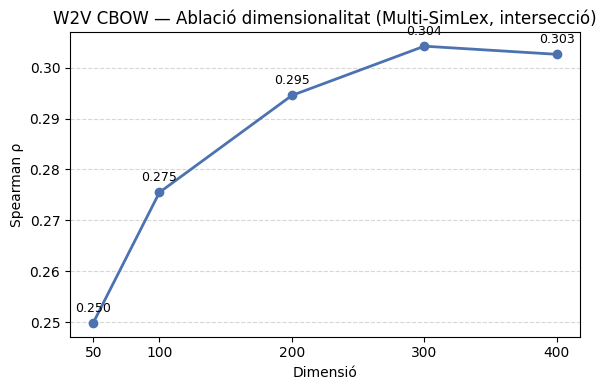

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(W2V_DIMS_LIST, abl_dim_w2v_df['spearman_rho'], marker='o', linewidth=2, color='#4C72B0')
for dim, rho in zip(W2V_DIMS_LIST, abl_dim_w2v_df['spearman_rho']):
    ax.annotate(f'{rho:.3f}', (dim, rho), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_xlabel('Dimensió'); ax.set_ylabel('Spearman ρ')
ax.set_title('W2V CBOW — Ablació dimensionalitat (Multi-SimLex, intersecció)')
ax.set_xticks(W2V_DIMS_LIST); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_dim_w2v.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.4 Ablació — efecte de la dimensionalitat (fastText CBOW)

Dimensions: **50, 100, 200, 300**d sobre ~50M tokens (CBOW, window=5, min_n=3, max_n=6). 
S'avalua en mode **strict** (vocab vist) sobre la intersecció de parells coberts per tots quatre models.

In [43]:
FT_DIMS_LIST = [50, 100, 200, 300]  # claus enteres de ft_models

common_dim_ft = set.intersection(
    *[get_iv_set(multisimlex_pairs, ft_models[d].wv) for d in FT_DIMS_LIST]
)
pairs_dim_ft = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_dim_ft]
print(f'Intersecció FT dim: {len(pairs_dim_ft)} / {len(multisimlex_pairs)} parells')

abl_dim_ft_rows = []
for dim in FT_DIMS_LIST:
    res = eval_model(pairs_dim_ft, ft_models[dim].wv,
                     name=f'ft-cbow-{dim}d', all_pairs=multisimlex_pairs)
    abl_dim_ft_rows.append(res)
    print(f"  ft-cbow-{dim:3d}d  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_dim_ft_df = pd.DataFrame(abl_dim_ft_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_dim_ft_df.to_string(index=False))


Intersecció FT dim: 1888 / 1888 parells
  ft-cbow- 50d  rho=0.1498  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-100d  rho=0.1697  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-200d  rho=0.1802  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d  rho=0.1836  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

       model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
 ft-cbow-50d      0.149840         1888     1888             0.0             0.0
ft-cbow-100d      0.169655         1888     1888             0.0             0.0
ft-cbow-200d      0.180154         1888     1888             0.0             0.0
ft-cbow-300d      0.183632         1888     1888             0.0             0.0


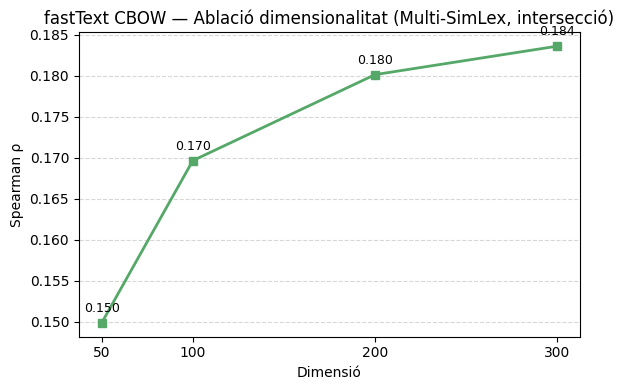

In [44]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(FT_DIMS_LIST, abl_dim_ft_df['spearman_rho'], marker='s', linewidth=2, color='#55A868')
for dim, rho in zip(FT_DIMS_LIST, abl_dim_ft_df['spearman_rho']):
    ax.annotate(f'{rho:.3f}', (dim, rho), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_xlabel('Dimensió'); ax.set_ylabel('Spearman ρ')
ax.set_title('fastText CBOW — Ablació dimensionalitat (Multi-SimLex, intersecció)')
ax.set_xticks(FT_DIMS_LIST); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_dim_ft.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.5 Ablació — efecte de la mida del corpus (Word2Vec CBOW, dim=300)

Corpus: **10M, 25M, 50M, all** tokens.

- **Spearman ρ** calculat sobre la intersecció de parells coberts per tots quatre models.
- **OOV stats** calculades sobre els 1.888 parells totals (cobertura real de cada model).

In [45]:
CORPUS_LABELS = ['10M', '25M', '50M', 'all']  # claus string de w2v_ablation

common_corpus_w2v = set.intersection(
    *[get_iv_set(multisimlex_pairs, w2v_ablation[lb].wv) for lb in CORPUS_LABELS]
)
pairs_corpus_w2v = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_corpus_w2v]
print(f'Intersecció W2V corpus: {len(pairs_corpus_w2v)} / {len(multisimlex_pairs)} parells')

abl_corpus_w2v_rows = []
for lb in CORPUS_LABELS:
    res = eval_model(pairs_corpus_w2v, w2v_ablation[lb].wv,
                     name=f'w2v-cbow-300d-{lb}', all_pairs=multisimlex_pairs)
    abl_corpus_w2v_rows.append(res)
    print(f"  w2v-cbow-300d-{lb:3s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_corpus_w2v_df = pd.DataFrame(abl_corpus_w2v_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_corpus_w2v_df.to_string(index=False))


Intersecció W2V corpus: 1184 / 1888 parells
  w2v-cbow-300d-10M  rho=0.2433  n=1184/1888  oov_pair=37.3%  oov_word=22.4%
  w2v-cbow-300d-25M  rho=0.2845  n=1184/1888  oov_pair=33.7%  oov_word=19.9%
  w2v-cbow-300d-50M  rho=0.3140  n=1184/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-300d-all  rho=0.3412  n=1184/1888  oov_pair=31.5%  oov_word=18.4%

            model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
w2v-cbow-300d-10M      0.243299         1184     1888        0.372881        0.223782
w2v-cbow-300d-25M      0.284508         1184     1888        0.337394        0.198623
w2v-cbow-300d-50M      0.314048         1184     1888        0.323093        0.188824
w2v-cbow-300d-all      0.341233         1184     1888        0.314619        0.184057


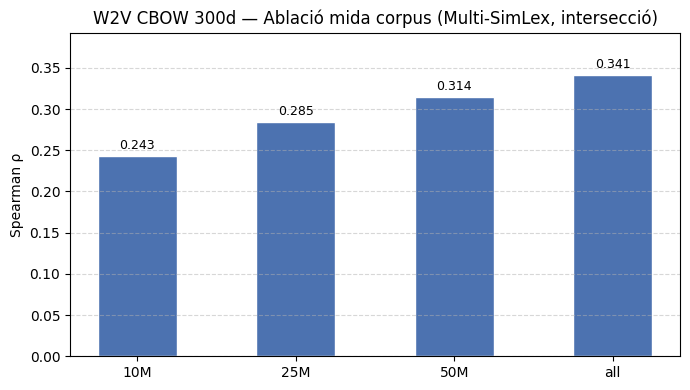

In [46]:
fig, ax = plt.subplots(figsize=(7,4))
rhos = abl_corpus_w2v_df['spearman_rho'].tolist()
x = range(len(CORPUS_LABELS))
bars = ax.bar(x, rhos, color='#4C72B0', edgecolor='white', width=0.5)
for b, v in zip(bars, rhos):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(CORPUS_LABELS)
ax.set_ylabel('Spearman ρ')
ax.set_title('W2V CBOW 300d — Ablació mida corpus (Multi-SimLex, intersecció)')
ax.set_ylim(0, max(rhos)*1.15); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_corpus_w2v.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.6 Ablació — efecte de la mida del corpus (fastText CBOW, dim=300)

Corpus: **10M, 25M, 50M, all** tokens. 

- **Spearman ρ** calculat sobre la intersecció de parells coberts per tots quatre models (mode strict, vocab vist).
- **OOV stats** calculades sobre els 1 888 parells totals (cobertura real de cada model).

In [47]:
common_corpus_ft = set.intersection(
    *[get_iv_set(multisimlex_pairs, ft_ablation[lb].wv) for lb in CORPUS_LABELS]
)
pairs_corpus_ft = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_corpus_ft]
print(f'Intersecció FT corpus: {len(pairs_corpus_ft)} / {len(multisimlex_pairs)} parells')

abl_corpus_ft_rows = []
for lb in CORPUS_LABELS:
    res = eval_model(pairs_corpus_ft, ft_ablation[lb].wv,
                     name=f'ft-cbow-300d-{lb}', all_pairs=multisimlex_pairs)
    abl_corpus_ft_rows.append(res)
    print(f"  ft-cbow-300d-{lb:3s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_corpus_ft_df = pd.DataFrame(abl_corpus_ft_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_corpus_ft_df.to_string(index=False))


Intersecció FT corpus: 1888 / 1888 parells
  ft-cbow-300d-10M  rho=0.1288  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-25M  rho=0.1643  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-50M  rho=0.1836  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-all  rho=0.1956  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

           model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
ft-cbow-300d-10M      0.128833         1888     1888             0.0             0.0
ft-cbow-300d-25M      0.164251         1888     1888             0.0             0.0
ft-cbow-300d-50M      0.183632         1888     1888             0.0             0.0
ft-cbow-300d-all      0.195584         1888     1888             0.0             0.0


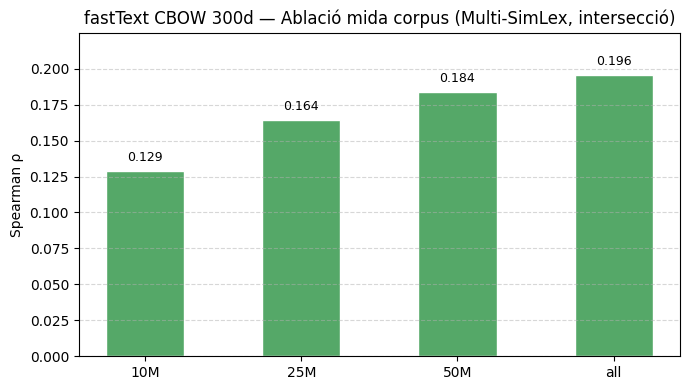

In [48]:
fig, ax = plt.subplots(figsize=(7,4))
rhos = abl_corpus_ft_df['spearman_rho'].tolist()
x = range(len(CORPUS_LABELS))
bars = ax.bar(x, rhos, color='#55A868', edgecolor='white', width=0.5)
for b, v in zip(bars, rhos):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(CORPUS_LABELS)
ax.set_ylabel('Spearman ρ')
ax.set_title('fastText CBOW 300d — Ablació mida corpus (Multi-SimLex, intersecció)')
ax.set_ylim(0, max(rhos)*1.15); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_corpus_ft.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.7 Comparativa models principals

Seleccionem la millor configuració de cada família a partir de les ablacions anteriors (corpus complet, dim=300) i les avaluem sobre tots els 1.888 parells Multi-SimLex per reflectir la cobertura real de cadascun.

| Model | Corpus | Dim | Mode |
|-------|--------|-----|------|
| `w2v-cbow-300d-all` | Wikicorpus complet | 300 | strict |
| `ft-propi-300d-all` | Wikicorpus complet | 300 | strict |
| `ft-propi-300d-all` | Wikicorpus complet | 300 | n-grams |
| `ft-oficial-300d` | Common Crawl | 300 | strict |
| `ft-oficial-300d` | Common Crawl | 300 | n-grams |

In [49]:
# W2V representatiu = corpus complet, dim=300 (w2v_ablation['all'])
models_principals = [
    ('w2v-cbow-300d-all strict', w2v_ablation['all'].wv, True),
    ('ft-propi-300d-all strict', ft_propi_strict,        True),
    ('ft-propi-300d-all ngrams', ft_propi_ngrams,        False),
    ('ft-oficial-300d strict',   ft_oficial_strict,      True),
    ('ft-oficial-300d ngrams',   ft_oficial_ngrams,      False),
]

comp_rows = []
for name, kv, strict in models_principals:
    res = eval_model(multisimlex_pairs, kv, name=name, strict=strict)
    comp_rows.append(res)
    print(f"  {name:30s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

simlex_df = pd.DataFrame(comp_rows)[['model', 'spearman_rho', 'n_evaluated', 'n_total',
                                      'oov_pair_ratio', 'oov_word_ratio']]
print()
print(simlex_df.to_string(index=False))


  w2v-cbow-300d-all strict        rho=0.3303  n=1294/1888  oov_pair=31.5%  oov_word=18.4%
  ft-propi-300d-all strict        rho=0.2176  n=1294/1888  oov_pair=31.5%  oov_word=18.4%
  ft-propi-300d-all ngrams        rho=0.1956  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-oficial-300d strict          rho=0.5193  n=1789/1888  oov_pair=5.2%  oov_word=2.7%
  ft-oficial-300d ngrams          rho=0.5034  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

                   model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
w2v-cbow-300d-all strict      0.330337         1294     1888        0.314619        0.184057
ft-propi-300d-all strict      0.217630         1294     1888        0.314619        0.184057
ft-propi-300d-all ngrams      0.195584         1888     1888        0.000000        0.000000
  ft-oficial-300d strict      0.519259         1789     1888        0.052436        0.027278
  ft-oficial-300d ngrams      0.503398         1888     1888        0.000000        0.0000

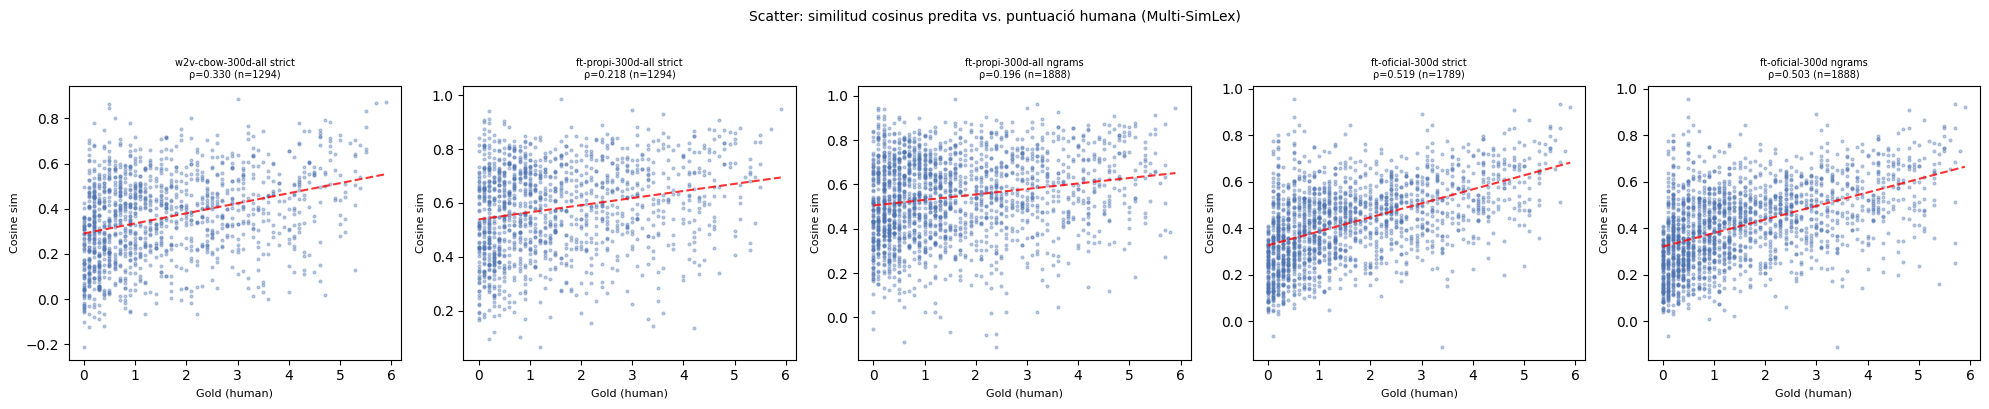

In [56]:
fig, axes = plt.subplots(1, len(models_principals), figsize=(4 * len(models_principals), 4))

for ax, (name, kv, strict) in zip(axes, models_principals):
    res = eval_model(multisimlex_pairs, kv, strict=strict)
    xs, ys = res['golds'], res['preds']
    rho = spearmanr(xs, ys).statistic if len(xs) > 2 else float('nan')
    
    ax.scatter(xs, ys, s=4, alpha=0.35, color='#4C72B0')
    
    if len(xs) > 1:
        # Línia de tendència (regressió lineal simple)
        z = np.polyfit(xs, ys, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(xs), max(xs), 100)
        ax.plot(x_trend, p(x_trend), color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(f"{name}\nρ={rho:.3f} (n={len(xs)})", fontsize=7)
    ax.set_xlabel('Gold (human)', fontsize=8)
    ax.set_ylabel('Cosine sim', fontsize=8)

plt.suptitle('Scatter: similitud cosinus predita vs. puntuació humana (Multi-SimLex)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('scatter_models_principals.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.8 Anàlisi per categoria gramatical (PoS)

Multi-SimLex distribueix els 1 888 parells en 4 categories: **nouns, verbs, adjectives, adverbs**.
Avaluem els 5 models principals per categoria.

In [51]:
from collections import defaultdict

pos_col = 'PoS'
pos_categories = sorted(multisimlex_df[pos_col].dropna().unique())

pos_pairs = defaultdict(list)
for _, row in multisimlex_df.iterrows():
    pos_pairs[row[pos_col]].append((
        str(row[W1_COL]).lower(),
        str(row[W2_COL]).lower(),
        float(row[SCORE_COL]),
    ))

model_cols = [name for name, _, _ in models_principals]
pos_rows = []
for pos in pos_categories:
    row = {'PoS': pos, 'n_parells': len(pos_pairs[pos])}
    for name, kv, strict in models_principals:
        res = eval_model(pos_pairs[pos], kv, strict=strict)
        row[name] = round(res['spearman_rho'], 4)
    pos_rows.append(row)

pos_df = pd.DataFrame(pos_rows).set_index('PoS')
print(pos_df[['n_parells'] + model_cols].to_string())


            n_parells  w2v-cbow-300d-all strict  ft-propi-300d-all strict  ft-propi-300d-all ngrams  ft-oficial-300d strict  ft-oficial-300d ngrams
PoS                                                                                                                                                
adjectives        245                    0.2503                    0.1510                    0.1422                  0.4281                  0.4006
adverbs           123                    0.4405                    0.3183                    0.2313                  0.4636                  0.3802
nouns            1051                    0.3799                    0.3106                    0.2906                  0.5851                  0.5759
verbs             469                    0.3373                    0.2954                    0.2719                  0.5144                  0.4768


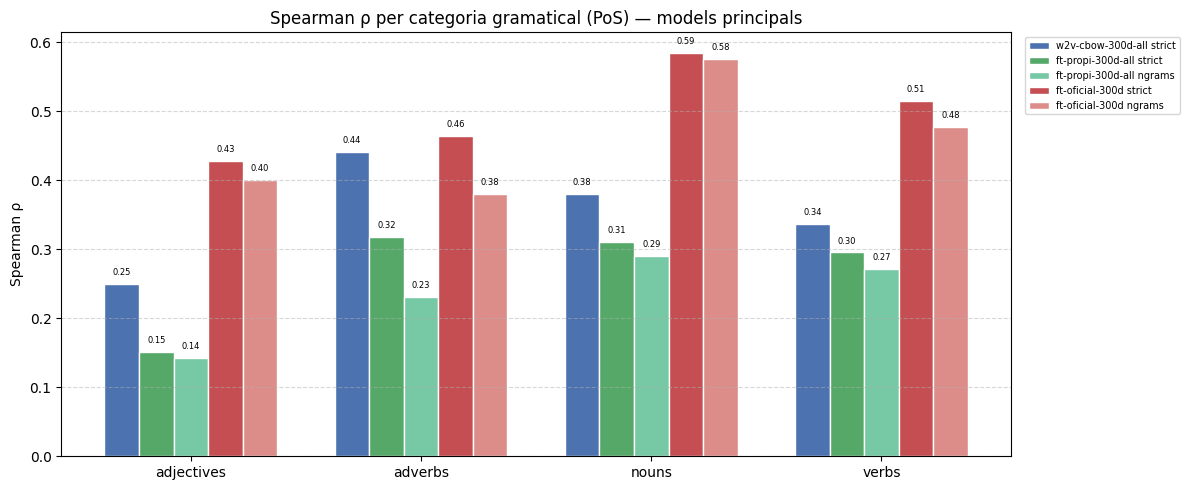

In [52]:
fig, ax = plt.subplots(figsize=(12,5))
bar_data = pos_df[model_cols]
n_pos = len(bar_data); n_mod = len(model_cols)
width = 0.15; x = np.arange(n_pos)
colors = ['#4C72B0','#55A868','#77C8A4','#C44E52','#DD8D89']

for i, (col, color) in enumerate(zip(model_cols, colors)):
    vals = bar_data[col].values.astype(float)
    rects = ax.bar(x + i*width - (n_mod-1)*width/2, vals, width,
                   label=col, color=color, edgecolor='white')
    for rect, val in zip(rects, vals):
        if not np.isnan(val):
            ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=6)

ax.set_xticks(x); ax.set_xticklabels(bar_data.index)
ax.set_ylabel('Spearman ρ')
ax.set_title('Spearman ρ per categoria gramatical (PoS) — models principals')
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pos_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Tasca 3 — Avaluació extrínseca (Spanish STS)

Tres aproximacions a la similitud de frases:
1. **Baseline cosinus** — mitjana simple i mitjana ponderada amb TF-IDF
2. **Model seqüencial siamès** — BiLSTM + Atenció, variants `frozen` i `trainable`
3. **Model BERT siamès** — BETO + pooling + MLP de regressió

Mètrica: correlació de **Pearson** sobre el conjunt de test.

### 4.1 Baseline cosinus (mitjana simple i ponderada amb TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def sentence_vector_mean(tokens, kv):
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)


def fit_tfidf(corpus_text):
    """Ajusta un TF-IDF sobre les frases d'un corpus."""
    vec = TfidfVectorizer(
        use_idf=True, smooth_idf=True, norm=None,
        tokenizer=tokenize, lowercase=False, token_pattern=None,
    )
    vec.fit(corpus_text)
    return vec


def sentence_vector_tfidf(text, tfidf, kv):
    row = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    weighted = np.zeros(kv.vector_size, dtype=np.float32)
    total_w = 0.0
    for idx, score in zip(row.indices, row.data):
        word = feature_names[idx]
        if word in kv:
            weighted += score * kv[word]
            total_w += score
    if total_w == 0:
        return sentence_vector_mean(tokenize(text), kv)
    return weighted / total_w


def evaluate_baseline(df, kv, mode="mean", tfidf=None):
    preds = []
    for s1, s2 in zip(df["sentence1"], df["sentence2"]):
        if mode == "mean":
            v1 = sentence_vector_mean(tokenize(s1), kv)
            v2 = sentence_vector_mean(tokenize(s2), kv)
        else:
            v1 = sentence_vector_tfidf(s1, tfidf, kv)
            v2 = sentence_vector_tfidf(s2, tfidf, kv)
        preds.append(cosine_sim(v1, v2))
    pearson, _ = pearsonr(preds, df["score"])
    return pearson, preds

In [ ]:
# Ajustem el TF-IDF només sobre el train per evitar fuga d'informació
all_train_sents = pd.concat([train_df["sentence1"], train_df["sentence2"]]).tolist()
tfidf = fit_tfidf(all_train_sents)
print(f"Vocabulari TF-IDF: {len(tfidf.get_feature_names_out())}")

Vocabulari TF-IDF: 11036


In [ ]:
# Models a comparar com a baseline cosinus (mateixos que a la tasca 2)
baselines_kvs = {
    f"w2v-{dim}d": w2v_models[dim].wv for dim in W2V_DIMS
}
baselines_kvs[f"ft-propi-{FT_DIM}d"] = ft_propi.wv
baselines_kvs["ft-oficial-300d"] = ft_oficial   # aprofita n-grams

baseline_results = []
for name, kv in baselines_kvs.items():
    p_mean, _ = evaluate_baseline(test_df, kv, mode="mean")
    p_tfidf, _ = evaluate_baseline(test_df, kv, mode="tfidf", tfidf=tfidf)
    baseline_results.append({"model": name, "mean": p_mean, "tfidf": p_tfidf})
    print(f"{name:25s}  mean={p_mean:.4f}  tfidf={p_tfidf:.4f}")

baseline_df = pd.DataFrame(baseline_results)
baseline_df

w2v-25d                    mean=0.5401  tfidf=0.5433
w2v-50d                    mean=0.5879  tfidf=0.5601
w2v-100d                   mean=0.6108  tfidf=0.5789
ft-propi-100d              mean=0.6320  tfidf=0.5870
ft-oficial-300d            mean=0.5605  tfidf=0.6500


,model,mean,tfidf
0,w2v-25d,0.540142,0.543253
1,w2v-50d,0.587913,0.560100
2,w2v-100d,0.610814,0.578925
3,ft-propi-100d,0.632015,0.587016
4,ft-oficial-300d,0.560478,0.650032


### 4.2 Model seqüencial siamès (BiLSTM + Atenció)

#### 4.2.1 Vocabulari, matriu d'embeddings i Dataset

In [ ]:
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1


def build_vocab_from_corpus(*dfs):
    """Construeix un vocabulari (paraula → índex) a partir de DataFrames de frases."""
    seen = set()
    for df in dfs:
        for col in ("sentence1", "sentence2"):
            for s in df[col]:
                seen.update(tokenize(s))
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for w in sorted(seen):
        if w not in vocab:
            vocab[w] = len(vocab)
    return vocab


def build_embedding_matrix(vocab, kv, dim):
    """Inicialitza la matriu d'embeddings amb el KV. Mots desconeguts: aleatoris."""
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0, 0.1, size=(len(vocab), dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0
    found = 0
    for word, idx in vocab.items():
        if word in (PAD_TOKEN, UNK_TOKEN):
            continue
        if word in kv:
            matrix[idx] = kv[word]
            found += 1
    print(f"Cobertura: {found}/{len(vocab)-2} ({100*found/(len(vocab)-2):.1f}%)")
    return matrix


# Construïm el vocabulari sobre tot l'STS i una matriu a partir del fastText propi
vocab_sts = build_vocab_from_corpus(train_df, dev_df, test_df)
print(f"Vocabulari STS: {len(vocab_sts):,}")
emb_matrix = build_embedding_matrix(vocab_sts, ft_propi.wv, FT_DIM)

Vocabulari STS: 11,906
Cobertura: 11904/11904 (100.0%)


In [ ]:
class STSDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode(self, text):
        toks = tokenize(text)[: self.max_len]
        ids = [self.vocab.get(t, UNK_IDX) for t in toks]
        mask = [1] * len(ids)
        pad = self.max_len - len(ids)
        ids += [PAD_IDX] * pad
        mask += [0] * pad
        return ids, mask

    def __getitem__(self, i):
        row = self.df.iloc[i]
        ids1, m1 = self.encode(row["sentence1"])
        ids2, m2 = self.encode(row["sentence2"])
        return {
            "input_ids_1": torch.tensor(ids1, dtype=torch.long),
            "attention_mask_1": torch.tensor(m1, dtype=torch.bool),
            "input_ids_2": torch.tensor(ids2, dtype=torch.long),
            "attention_mask_2": torch.tensor(m2, dtype=torch.bool),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


train_ds = STSDataset(train_df, vocab_sts)
dev_ds   = STSDataset(dev_df,   vocab_sts)
test_ds  = STSDataset(test_df,  vocab_sts)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print(f"Batches train/dev/test: {len(train_loader)}/{len(dev_loader)}/{len(test_loader)}")

Batches train/dev/test: 42/3/5


#### 4.2.2 Arquitectura siamesa (segons l'enunciat)

In [ ]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, final_hidden_size=32,
                 trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(
            emb_dim, hidden_size, batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

#### 4.2.3 Bucle d'entrenament i avaluació

In [ ]:
def evaluate_pearson(model, loader):
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            p = model(batch["input_ids_1"], batch["attention_mask_1"],
                      batch["input_ids_2"], batch["attention_mask_2"])
            preds.extend(p.cpu().numpy().tolist())
            golds.extend(batch["score"].cpu().numpy().tolist())
    return pearsonr(preds, golds)[0]


def train_regressor(model, train_loader, dev_loader, epochs, lr, name="model"):
    model.to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_dev, best_state = -1.0, None

    for ep in range(epochs):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optim.zero_grad()
            preds = model(batch["input_ids_1"], batch["attention_mask_1"],
                          batch["input_ids_2"], batch["attention_mask_2"])
            loss = loss_fn(preds, batch["score"])
            loss.backward()
            optim.step()
            total += loss.item()
        dev_p = evaluate_pearson(model, dev_loader)
        print(f"[{name}] epoch {ep+1}/{epochs}  "
              f"train_loss={total/len(train_loader):.4f}  dev_pearson={dev_p:.4f}")
        if dev_p > best_dev:
            best_dev = dev_p
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_dev

#### 4.2.4 Variants `frozen` i `trainable` (suggerides per l'enunciat)

In [ ]:
# Variant A: embeddings congelats
torch.manual_seed(SEED)
siamese_frozen = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=False)
siamese_frozen, dev_frozen = train_regressor(
    siamese_frozen, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-frozen",
)
test_frozen = evaluate_pearson(siamese_frozen, test_loader)
print(f"\n→ Pearson test (frozen): {test_frozen:.4f}")

[siamese-frozen] epoch 1/10  train_loss=2.3098  dev_pearson=0.1850
[siamese-frozen] epoch 2/10  train_loss=1.0968  dev_pearson=0.2716
[siamese-frozen] epoch 3/10  train_loss=1.1318  dev_pearson=0.3251
[siamese-frozen] epoch 4/10  train_loss=1.0901  dev_pearson=0.3799
[siamese-frozen] epoch 5/10  train_loss=1.0309  dev_pearson=0.4213
[siamese-frozen] epoch 6/10  train_loss=0.9944  dev_pearson=0.4639
[siamese-frozen] epoch 7/10  train_loss=0.9494  dev_pearson=0.5185
[siamese-frozen] epoch 8/10  train_loss=0.8651  dev_pearson=0.5284
[siamese-frozen] epoch 9/10  train_loss=0.8398  dev_pearson=0.5780
[siamese-frozen] epoch 10/10  train_loss=0.7805  dev_pearson=0.6073

→ Pearson test (frozen): 0.6126


In [ ]:
# Variant B: embeddings entrenables (fine-tuning de la matriu)
torch.manual_seed(SEED)
siamese_train = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=True)
siamese_train, dev_train = train_regressor(
    siamese_train, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-trainable",
)
test_train = evaluate_pearson(siamese_train, test_loader)
print(f"\n→ Pearson test (trainable): {test_train:.4f}")

[siamese-trainable] epoch 1/10  train_loss=2.3062  dev_pearson=0.1954
[siamese-trainable] epoch 2/10  train_loss=1.0832  dev_pearson=0.2787
[siamese-trainable] epoch 3/10  train_loss=1.0899  dev_pearson=0.3314
[siamese-trainable] epoch 4/10  train_loss=0.9563  dev_pearson=0.3488
[siamese-trainable] epoch 5/10  train_loss=0.7448  dev_pearson=0.3164
[siamese-trainable] epoch 6/10  train_loss=0.4665  dev_pearson=0.3103
[siamese-trainable] epoch 7/10  train_loss=0.3699  dev_pearson=0.3492
[siamese-trainable] epoch 8/10  train_loss=0.2941  dev_pearson=0.3635
[siamese-trainable] epoch 9/10  train_loss=0.2183  dev_pearson=0.3237
[siamese-trainable] epoch 10/10  train_loss=0.2169  dev_pearson=0.3424

→ Pearson test (trainable): 0.4582


### 4.3 Model BERT siamès (BETO)

In [ ]:
from transformers import AutoTokenizer, AutoModel

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


class STSBertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        e1 = self.tokenizer(row["sentence1"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        e2 = self.tokenizer(row["sentence2"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        return {
            "input_ids_1": e1["input_ids"].squeeze(0),
            "attention_mask_1": e1["attention_mask"].squeeze(0),
            "input_ids_2": e2["input_ids"].squeeze(0),
            "attention_mask_2": e2["attention_mask"].squeeze(0),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


bert_train = DataLoader(STSBertDataset(train_df, bert_tokenizer), batch_size=16, shuffle=True)
bert_dev   = DataLoader(STSBertDataset(dev_df,   bert_tokenizer), batch_size=16)
bert_test  = DataLoader(STSBertDataset(test_df,  bert_tokenizer), batch_size=16)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

c:\Users\irenm\PLH\plh\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\irenm\.cache\huggingface\hub\models--dccuchile--bert-base-spanish-wwm-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [ ]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL_NAME, final_hidden_size=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.pool = MeanPooling()
        hidden = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

In [ ]:
torch.manual_seed(SEED)
beto_model = BETOSiameseRegressor()
beto_model, dev_bert = train_regressor(
    beto_model, bert_train, bert_dev,
    epochs=BERT_EPOCHS, lr=BERT_LR, name="beto-siamese",
)
test_bert = evaluate_pearson(beto_model, bert_test)
print(f"\n→ Pearson test (BETO siamès): {test_bert:.4f}")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[beto-siamese] epoch 1/4  train_loss=1.3351  dev_pearson=0.3451
[beto-siamese] epoch 2/4  train_loss=0.9380  dev_pearson=0.5794
[beto-siamese] epoch 3/4  train_loss=0.5292  dev_pearson=0.6941
[beto-siamese] epoch 4/4  train_loss=0.2576  dev_pearson=0.6993

→ Pearson test (BETO siamès): 0.7063


## 5. Anàlisi opcional — Robustesa a pertorbacions

Construïm tres versions pertorbades del test STS (sense accents, errors tipogràfics, lowercase agressiu) per veure com es degrada cada model. L'enunciat suggereix aquesta anàlisi com a opcional.

In [ ]:
def remove_accents(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )


def add_typos(text, prob=0.10, rng=None):
    if rng is None:
        rng = random.Random(SEED)
    chars = list(text)
    out = []
    i = 0
    while i < len(chars):
        c = chars[i]
        if c.isalpha() and rng.random() < prob:
            op = rng.choice(["swap", "delete", "duplicate"])
            if op == "swap" and i + 1 < len(chars) and chars[i+1].isalpha():
                out.append(chars[i+1]); out.append(c); i += 2; continue
            elif op == "delete":
                i += 1; continue
            elif op == "duplicate":
                out.append(c); out.append(c); i += 1; continue
        out.append(c); i += 1
    return "".join(out)


def perturb_df(df, mode):
    df_p = df.copy()
    rng = random.Random(SEED)
    if mode == "no_accents":
        df_p["sentence1"] = df_p["sentence1"].apply(remove_accents)
        df_p["sentence2"] = df_p["sentence2"].apply(remove_accents)
    elif mode == "typos":
        df_p["sentence1"] = df_p["sentence1"].apply(lambda t: add_typos(t, 0.10, random.Random(SEED)))
        df_p["sentence2"] = df_p["sentence2"].apply(lambda t: add_typos(t, 0.10, random.Random(SEED+1)))
    return df_p


# Generem les variants pertorbades del test
test_clean   = test_df
test_no_acc  = perturb_df(test_df, "no_accents")
test_typos   = perturb_df(test_df, "typos")

print("Original :", test_clean.iloc[0]["sentence1"])
print("Sense ac.:", test_no_acc.iloc[0]["sentence1"])
print("Typos    :", test_typos.iloc[0]["sentence1"])

Original : El viceministro de Política Interior y Seguridad Jurídica, José Vicente Rangel Ávalos, señaló que antes de que el pueblo eligiera al presidente Hugo Chávez, “La tortura estaba institucionalizada y el asesinato político era frecuente” en Venezuela.
Sense ac.: El viceministro de Politica Interior y Seguridad Juridica, Jose Vicente Rangel Avalos, senalo que antes de que el pueblo eligiera al presidente Hugo Chavez, “La tortura estaba institucionalizada y el asesinato politico era frecuente” en Venezuela.
Typos    : E vicemiinstor de Política Interio y Seguridad Jurídica, José VVicente Range Ávvalos, señaló que antse de que el pueblo eligierra al presidente Hgo Chávez, “LLa ttortura estaba institucionnlaizdaa y el asesinnato poltico era freeccuente” en Vezuela.


In [ ]:
# Re-avaluació dels baselines cosinus (mean) sobre les 3 versions del test
robustness_rows = []
for name, kv in baselines_kvs.items():
    row = {"model": name}
    for split_name, split_df in [("clean", test_clean),
                                  ("no_accents", test_no_acc),
                                  ("typos", test_typos)]:
        p, _ = evaluate_baseline(split_df, kv, mode="mean")
        row[split_name] = p
    robustness_rows.append(row)

robustness_df = pd.DataFrame(robustness_rows)
robustness_df["delta_no_acc"] = robustness_df["clean"] - robustness_df["no_accents"]
robustness_df["delta_typos"]  = robustness_df["clean"] - robustness_df["typos"]
robustness_df

,model,clean,no_accents,typos,delta_no_acc,delta_typos
0,w2v-25d,0.540142,0.550337,0.402585,-0.010195,0.137557
1,w2v-50d,0.587913,0.600246,0.447950,-0.012333,0.139963
2,w2v-100d,0.610814,0.617734,0.445475,-0.006920,0.165339
3,ft-propi-100d,0.632015,0.631708,0.544732,0.000307,0.087283
4,ft-oficial-300d,0.560478,0.559054,0.490818,0.001424,0.069661


## 6. Resum de resultats

Reagrupem tots els números en taules úniques per facilitar la redacció de l'informe.

In [ ]:
print("="*70)
print("TASCA 2 — Multi-SimLex (Spearman)")
print("="*70)
print(simlex_df.to_string(index=False))

print("\n" + "="*70)
print("TASCA 3 — Spanish STS (Pearson)")
print("="*70)
sts_summary = baseline_df.copy()
sts_summary = sts_summary.rename(columns={"mean": "baseline_mean", "tfidf": "baseline_tfidf"})
print("\n[Baseline cosinus]")
print(sts_summary.to_string(index=False))

print("\n[Models neurals — test Pearson]")
print(f"  siamese-frozen     : {test_frozen:.4f}  (dev: {dev_frozen:.4f})")
print(f"  siamese-trainable  : {test_train:.4f}  (dev: {dev_train:.4f})")
print(f"  beto-siamese       : {test_bert:.4f}   (dev: {dev_bert:.4f})")

print("\n" + "="*70)
print("ROBUSTESA — Pearson amb test pertorbat (baseline mean)")
print("="*70)
print(robustness_df.to_string(index=False))

TASCA 2 — Multi-SimLex (Spearman)
                    model  spearman  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
                  w2v-25d  0.233343         1177     1888        0.376589        0.225636
                  w2v-50d  0.251023         1177     1888        0.376589        0.225636
                 w2v-100d  0.251311         1177     1888        0.376589        0.225636
            ft-propi-100d  0.210678         1888     1888        0.000000        0.000000
 ft-oficial-300d (strict)  0.519259         1789     1888        0.052436        0.027278
ft-oficial-300d (n-grams)  0.503398         1888     1888        0.000000        0.027278

TASCA 3 — Spanish STS (Pearson)

[Baseline cosinus]
          model  baseline_mean  baseline_tfidf
        w2v-25d       0.540142        0.543253
        w2v-50d       0.587913        0.560100
       w2v-100d       0.610814        0.578925
  ft-propi-100d       0.632015        0.587016
ft-oficial-300d       0.560478        0.650032



In [ ]:
# Guardem totes les taules per poder-les recuperar més tard a l'informe
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

simlex_df.to_csv(RESULTS_DIR / "simlex_results.csv", index=False)
baseline_df.to_csv(RESULTS_DIR / "sts_baseline_results.csv", index=False)
robustness_df.to_csv(RESULTS_DIR / "robustness_results.csv", index=False)

neural_results = pd.DataFrame([
    {"model": "siamese-frozen",    "dev_pearson": dev_frozen, "test_pearson": test_frozen},
    {"model": "siamese-trainable", "dev_pearson": dev_train,  "test_pearson": test_train},
    {"model": "beto-siamese",      "dev_pearson": dev_bert,   "test_pearson": test_bert},
])
neural_results.to_csv(RESULTS_DIR / "sts_neural_results.csv", index=False)
print("Resultats guardats a", RESULTS_DIR)

Resultats guardats a results
